<a href="https://colab.research.google.com/github/Yeabebe/earthquake-detection-ai/blob/main/esp32_vibration_tinyml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INSTALL & IMPORT LIBRARIES

In [1]:
!pip install tensorflow scikit-learn pandas matplotlib requests

import requests
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


FETCH DATA FROM BACKEND API

In [2]:
API_URL = "https://apiearthquake.yonasproject.cloud/api/samples?page=1"

response = requests.get(API_URL)

data = response.json()

print("API Connected Successfully")

API Connected Successfully


EXTRACT SENSOR DATA

In [3]:
samples = data['data']

df = pd.DataFrame(samples)

print("\nDataset Loaded Successfully")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


Dataset Loaded Successfully
                                     id  deviceId                 timestamp  \
0  33b4f6d3-a51c-4101-9ab1-a45eafc765a1  esp32-01  2026-05-21T20:07:18.442Z   
1  385e5161-3047-4204-88d1-336ec3eb3b07  esp32-01  2026-05-20T22:55:43.020Z   
2  d6feadcc-fae2-4723-bb36-66f1a1d8948d  esp32-01  2026-05-20T22:55:41.780Z   
3  4bcb9308-78da-44bd-a774-1525bed7f3f2  esp32-01  2026-05-20T22:55:39.329Z   
4  aeb2685d-4979-4aad-bd7e-9640ccafe060  esp32-01  2026-05-20T22:55:36.529Z   

       x      y      z  magnitude       pga label  
0  0.020  0.010  0.980   0.980255  0.019745  None  
1 -0.192 -0.054  0.908   0.929647  0.070353  None  
2 -0.200  0.304 -2.000   2.032834  1.032834  None  
3 -0.200  0.304 -2.000   2.032834  1.032834  None  
4 -0.490  2.000  0.875   2.237348  1.237348  None  

Dataset Shape:
(20, 9)


SELECT IMPORTANT FEATURES

In [4]:
df = df[[
    'x',
    'y',
    'z',
    'magnitude',
    'pga'
]]

print("\nSelected Features")
print(df.head())


Selected Features
       x      y      z  magnitude       pga
0  0.020  0.010  0.980   0.980255  0.019745
1 -0.192 -0.054  0.908   0.929647  0.070353
2 -0.200  0.304 -2.000   2.032834  1.032834
3 -0.200  0.304 -2.000   2.032834  1.032834
4 -0.490  2.000  0.875   2.237348  1.237348


CREATE LABELS

In [5]:
def classify_vibration(pga):

    if pga < 0.05:
        return 0

    else:
        return 1


df['label'] = df['pga'].apply(classify_vibration)

print("\nLabels Created Successfully")

print(df['label'].value_counts())


Labels Created Successfully
label
1    18
0     2
Name: count, dtype: int64


PREPARE INPUTS & OUTPUTS

In [6]:
X = df[['x', 'y', 'z', 'magnitude', 'pga']]

y = df['label']

print("\nFeatures Prepared Successfully")
print(X.head())



Features Prepared Successfully
       x      y      z  magnitude       pga
0  0.020  0.010  0.980   0.980255  0.019745
1 -0.192 -0.054  0.908   0.929647  0.070353
2 -0.200  0.304 -2.000   2.032834  1.032834
3 -0.200  0.304 -2.000   2.032834  1.032834
4 -0.490  2.000  0.875   2.237348  1.237348


TRAIN / TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))



Training Samples: 16
Testing Samples: 4


FEATURE SCALING

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed")


Feature Scaling Completed


BUILD TINYML MODEL

In [9]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        2,
        activation='softmax'
    )
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


COMPILE MODEL

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Compiled Successfully")

model.summary()



Model Compiled Successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 754 (2.95 KB)

 Trainable params: 754 (2.95 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN MODEL

In [11]:
history = model.fit(

    X_train,
    y_train,

    epochs=20,

    batch_size=16,

    validation_split=0.1,

    verbose=1
)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 1.0000 - val_loss: 0.5582
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7143 - loss: 0.6605 - val_accuracy: 1.0000 - val_loss: 0.5477
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6429 - loss: 0.7052 - val_accuracy: 1.0000 - val_loss: 0.5375
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6429 - loss: 0.6481 - val_accuracy: 1.0000 - val_loss: 0.5276
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6429 - loss: 0.6551 - val_accuracy: 1.0000 - val_loss: 0.5178
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.7143 - loss: 0.6257 - val_accuracy: 1.0000 - val_loss: 0.5080
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7857 - loss: 0.5942 - val_accuracy: 1.0000 - val_loss: 0.4984
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7143 - loss: 0.5947 - val_accuracy: 1.0000 - val_loss: 0.4

EVALUATE MODEL

In [12]:
y_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nCLASSIFICATION REPORT")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred
    )
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

Model Accuracy: 0.7500

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CONFUSION MATRIX

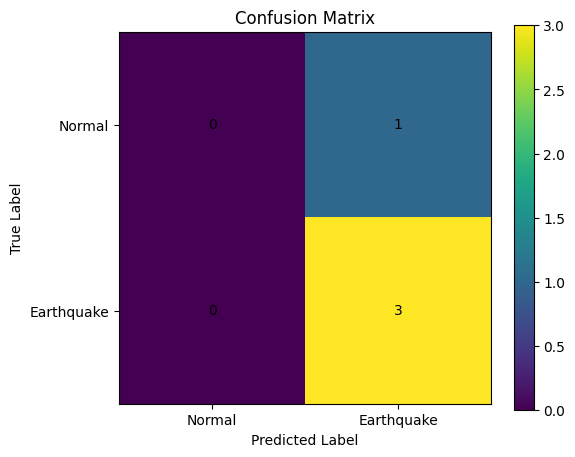

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0,1],
    ['Normal', 'Earthquake']
)

plt.yticks(
    [0,1],
    ['Normal', 'Earthquake']
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()


TRAINING PERFORMANCE GRAPH

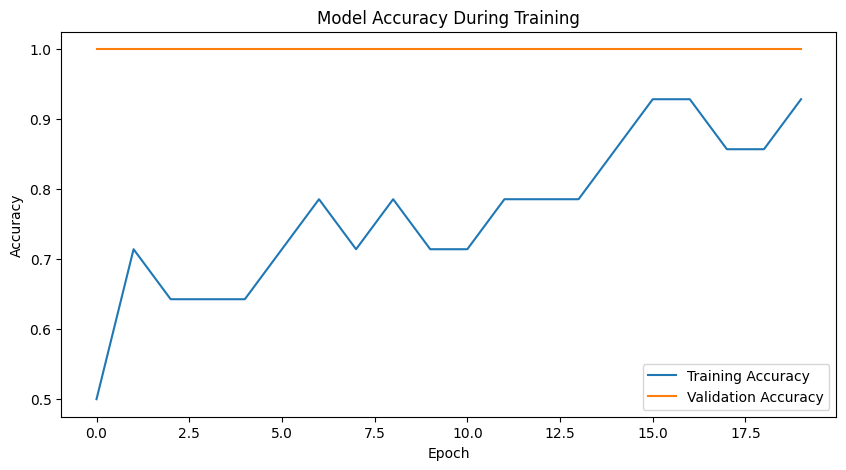

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Model Accuracy During Training')

plt.legend()

plt.show()


PREDICTION FUNCTION

In [15]:
def predict_vibration(
    x,
    y,
    z,
    magnitude,
    pga
):

    sample = pd.DataFrame([[
        x,
        y,
        z,
        magnitude,
        pga
    ]],
    columns=[
        'x',
        'y',
        'z',
        'magnitude',
        'pga'
    ])

    sample = scaler.transform(sample)

    prediction = model.predict(sample)

    predicted_class = np.argmax(prediction)

    classes = [
        "Normal Vibration",
        "Possible Earthquake"
    ]

    return classes[predicted_class]



TEST PREDICTION

In [16]:
result = predict_vibration(

    0.02,
    0.01,
    0.98,
    0.98,
    0.019
)

print("\nPREDICTION RESULT")
print("-----------------")
print(result)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

PREDICTION RESULT
-----------------
Possible Earthquake


SAVE KERAS MODEL

In [19]:
model.save(
    "esp32_vibration_model.keras"
)

print("\nKeras Model Saved Successfully")



Keras Model Saved Successfully


CONVERT TO TFLITE

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open(
    "esp32_vibration_model.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("\nTFLite Model Saved Successfully")


Saved artifact at '/tmp/tmpayy7tbxx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136262405837776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262405838352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262405840464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262405837968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262405839504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136262405841040: TensorSpec(shape=(), dtype=tf.resource, name=None)

TFLite Model Saved Successfully


DOWNLOAD MODELS

In [20]:
from google.colab import files

files.download(
    "esp32_vibration_model.keras"
)

files.download(
    "esp32_vibration_model.tflite"
)

print("\nAll Tasks Completed Successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All Tasks Completed Successfully
